In [18]:
import pandas as pd
import numpy as np
import ast, glob, os

geo_cols = ["Other", "City", "County", "State", "Region", "Country"]
def is_abstained_answer(x):
    if pd.isna(x):
        return True
    return "do not have enough information" in str(x).lower()
def safe_parse(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

def clean(x):
    return str(x).strip().lower()

def question_hierarchy(row):
    return [
        str(row[c]).strip()
        for c in geo_cols
        if pd.notna(row[c]) and str(row[c]).strip()
    ]

def hierarchy_distance(h1, h2):
    h1 = [clean(x) for x in h1]
    h2 = [clean(x) for x in h2]

    set1 = set(h1)
    set2 = set(h2)
    common = set1 & set2

    if not common:
        return float("inf")

    lca = None
    for h in h1:
        if h in common:
            lca = h
            break

    d1 = h1.index(lca)
    d2 = h2.index(lca)

    return d1 + d2

def flatten_geomappings(retrieved_geomappings):
    parsed = safe_parse(retrieved_geomappings)

    mappings = []

    for item in parsed:
        if isinstance(item, list):
            for g in item:
                if isinstance(g, dict):
                    mappings.append(g)
        elif isinstance(item, dict):
            mappings.append(item)

    return mappings

def classify_geo_relation(row):
    q_h = question_hierarchy(row)

    if not q_h:
        return {
            "min_geo_distance": None,
            "best_geo_relation": "no_question_geo"
        }

    mappings = flatten_geomappings(row["retrieved_geomappings"])

    if not mappings:
        return {
            "min_geo_distance": None,
            "best_geo_relation": "no_retrieved_geo"
        }

    q_top = clean(q_h[0])
    distances = []
    relations = []

    for g in mappings:
        node_h = g.get("hierarchy", [])
        node_scope = clean(g.get("geo_scope", ""))

        d = hierarchy_distance(q_h, node_h)
        distances.append(d)

        node_h_clean = [clean(x) for x in node_h]

        if node_scope == q_top:
            relations.append("same_scope")
        elif q_top in node_h_clean:
            relations.append("same_scope")
        elif any(clean(x) == node_scope for x in q_h[1:]):
            relations.append("parent_scope")
        elif d == float("inf"):
            relations.append("unrelated")
        else:
            relations.append("sibling_or_near_miss")

    min_d = min(distances)

    priority = {
        "same_scope": 0,
        "parent_scope": 1,
        "sibling_or_near_miss": 2,
        "unrelated": 3
    }

    best_relation = sorted(relations, key=lambda x: priority[x])[0]

    return {
        "min_geo_distance": min_d,
        "best_geo_relation": best_relation
    }

In [19]:
files = glob.glob("outputs/*.csv")

summary_rows = []
all_dfs = {}



In [20]:
summary_rows = []
all_dfs = {}

for f in files:
    df = pd.read_csv(f)
    name = os.path.basename(f)

    geo_info = df.apply(classify_geo_relation, axis=1, result_type="expand")
    df = pd.concat([df, geo_info], axis=1)

    method = (
        "exact_match" if "exact_match" in name
        else "granularity" if "granularity" in name
        else "graph_match" if "graph_match" in name
        else "risk_aware" if "risk" in name
        else "vanilla"
    )

    embedding = "bge-small" if "bge-small" in name else "bge-base"
    llm = "gemma" if "gemma" in name else "gpt-oss"
    model = f"{embedding}+{llm}"

    df["location_group"] = np.where(
        df["Location Dependent"].astype(str).str.upper().eq("YES"),
        "Location-dependent",
        "Non-location"
    )

    for location_group, gdf in df.groupby("location_group"):
        summary_rows.append({
            "location_group": location_group,
            "method": method,
            "model": model,
            "n": len(gdf),

            "mean_answer_similarity": gdf["rag_answer_similarity"].mean(),
            "median_answer_similarity": gdf["rag_answer_similarity"].median(),

            "same_scope_rate": (gdf["best_geo_relation"] == "same_scope").mean(),
            "parent_scope_rate": (gdf["best_geo_relation"] == "parent_scope").mean(),
            "sibling_near_miss_rate": (gdf["best_geo_relation"] == "sibling_or_near_miss").mean(),
            "unrelated_rate": (gdf["best_geo_relation"] == "unrelated").mean(),

            "mean_geo_distance": gdf["min_geo_distance"].replace(float("inf"), np.nan).mean(),
            "abstention_rate": gdf["rag_answer"].apply(is_abstained_answer).mean()
        })

    all_dfs[name] = df

summary = pd.DataFrame(summary_rows)

In [38]:
metric_cols = [
    "mean_answer_similarity",
    "same_scope_rate",
    "parent_scope_rate",
    "sibling_near_miss_rate",
    "unrelated_rate",
    "mean_geo_distance",
    "abstention_rate"
]

final_table = summary.pivot_table(
    index=["method"],
    columns=["model", "location_group"],
    values=metric_cols,
    aggfunc="first"
)

# Put metrics as rows, methods under each metric
final_table = final_table.stack(level=0)

# Rename row index cleanly
final_table.index.names = ["method", "metric"]

# Optional: metrics first, then method
final_table = final_table.reorder_levels(["metric", "method"]).sort_index()

final_table = final_table.round(3)

final_table

/var/folders/v7/f91h56z91wl845tw3glrybw40000gn/T/ipykernel_16101/1405990706.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  final_table = final_table.stack(level=0)


model                                  bge-base+gemma               \
location_group                     Location-dependent Non-location   
metric                 method                                        
abstention_rate        exact_match              0.738        0.548   
                       granularity              0.747        0.544   
                       graph_match              0.778        0.667   
                       risk_aware               0.765        0.531   
                       vanilla                  0.719        0.452   
mean_answer_similarity exact_match              0.521        0.579   
                       granularity              0.524        0.589   
                       graph_match              0.505        0.539   
                       risk_aware               0.515        0.594   
                       vanilla                  0.535        0.626   
mean_geo_distance      exact_match              0.011        0.000   
                       granularity              0.433        0.147   
                       graph_match              0.128        0.000   
                       risk_aware               0.317        0.075   
                       vanilla                  0.472        0.241   
parent_scope_rate      exact_match              0.000        0.000   
                       granularity              0.303        0.092   
                       graph_match              0.113        0.000   
                       risk_aware               0.253        0.061   
                       vanilla                  0.353        0.145   
same_scope_rate        exact_match              0.837        0.974   
                       granularity              0.566        0.811   
                       graph_match              0.873        1.000   
                       risk_aware               0.647        0.864   
                       vanilla                  0.511        0.684   
sibling_near_miss_rate exact_match              0.000        0.000   
                       granularity              0.041        0.022   
                       graph_match              0.000        0.000   
                       risk_aware               0.014        0.004   
                       vanilla                  0.027        0.026   
unrelated_rate         exact_match              0.000        0.000   
                       granularity              0.032        0.070   
                       graph_match              0.009        0.000   
                       risk_aware               0.018        0.053   
                       vanilla                  0.072        0.123   

model                                bge-base+gpt-oss               \
location_group                     Location-dependent Non-location   
metric                 method                                        
abstention_rate        exact_match              0.615        0.351   
                       granularity              0.557        0.281   
                       graph_match              0.602        0.465   
                       risk_aware               0.579        0.311   
                       vanilla                  0.489        0.219   
mean_answer_similarity exact_match              0.571        0.650   
                       granularity              0.589        0.680   
                       graph_match              0.571        0.614   
                       risk_aware               0.581        0.668   
                       vanilla                  0.611        0.702   
mean_geo_distance      exact_match              0.011        0.000   
                       granularity              0.433        0.147   
                       graph_match              0.128        0.000   
                       risk_aware               0.317        0.075   
                       vanilla                  0.472        0.241   
parent_scope_rate      exact_match              0.000        0.000   
         

In [22]:
final_table.to_csv("results.csv")

In [23]:
# | Method          | Geo accuracy               | Answer quality      | Abstention |
# | --------------- | -------------------------- | ------------------- | ---------- |
# | Exact match     | Very high                  | Medium              | Very high  |
# | Vanilla         | Low                        | High                | Low        |
# | Granularity     | Medium                     | Medium–high         | Medium     |
# | Graph match     | Very high                  | Low–medium          | High       |
# | Full risk-aware | Medium–high (best balance) | Medium–high to high | Medium     |


In [44]:
metrics_to_keep = [
    "same_scope_rate",
    "mean_answer_similarity",
    "abstention_rate"
]

method_name_map = {
    "exact_match": "Exact keyword match",
    "vanilla": "Similarity-only",
    "granularity": "Granularity-only",
    "graph_match": "Graph match",
    "risk_aware": "Full geo-first"
}

method_order = [
    "exact_match",
    "vanilla",
    "granularity",
    "graph_match",
    "risk_aware"
]

# keep only selected metrics
ft = final_table.loc[
    final_table.index.get_level_values("metric").isin(metrics_to_keep)
].copy()

# average across model level, keeping location_group
avg_from_final = ft.groupby(level="location_group", axis=1).mean().round(3)

# reorder rows
avg_from_final = avg_from_final.loc[
    pd.MultiIndex.from_product(
        [metrics_to_keep, method_order],
        names=["metric", "method"]
    )
]

avg_from_final

/var/folders/v7/f91h56z91wl845tw3glrybw40000gn/T/ipykernel_16101/893870476.py:29: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  avg_from_final = ft.groupby(level="location_group", axis=1).mean().round(3)


location_group                      Location-dependent  Non-location
metric                 method                                       
same_scope_rate        exact_match               0.835         0.948
                       vanilla                   0.518         0.660
                       granularity               0.559         0.794
                       graph_match               0.873         1.000
                       risk_aware                0.615         0.829
mean_answer_similarity exact_match               0.557         0.633
                       vanilla                   0.586         0.672
                       granularity               0.566         0.650
                       graph_match               0.551         0.589
                       risk_aware                0.563         0.642
abstention_rate        exact_match               0.680         0.448
                       vanilla                   0.605         0.359
                       granularity               0.659         0.417
                       graph_match               0.687         0.574
                       risk_aware                0.663         0.438

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

best_model = "bge-small+gpt-oss"   # change if needed

plot_metrics = [
    "mean_answer_similarity",
    "same_scope_rate",
    "parent_scope_rate",
    "sibling_near_miss_rate",
    "unrelated_rate",
    "mean_geo_distance",
    "abstention_rate"
]

methods_order = [
    "exact_match",
    "vanilla",
    "granularity",
    "graph_match",
    "risk_aware"
]

method_labels = {
    "exact_match": "Exact keyword",
    "vanilla": "Similarity-only",
    "granularity": "Granularity",
    "graph_match": "Graph match",
    "risk_aware": "Full geo-first"
}

metric_labels = {
    "mean_answer_similarity": "Answer quality",
    "same_scope_rate": "Same-scope rate",
    "parent_scope_rate": "Parent-scope rate",
    "sibling_near_miss_rate": "Sibling / near-miss rate",
    "unrelated_rate": "Unrelated rate",
    "mean_geo_distance": "Mean geo distance",
    "abstention_rate": "Abstention rate"
}

plot_source = summary[summary["model"] == best_model].copy()

plot_source["method"] = pd.Categorical(
    plot_source["method"],
    categories=methods_order,
    ordered=True
)

plot_source["location_group"] = pd.Categorical(
    plot_source["location_group"],
    categories=["Location-dependent", "Non-location"],
    ordered=True
)

plot_source = plot_source.sort_values(["method", "location_group"])

/var/folders/v7/f91h56z91wl845tw3glrybw40000gn/T/ipykernel_16101/3742499053.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = plot_source.pivot_table(
/var/folders/v7/f91h56z91wl845tw3glrybw40000gn/T/ipykernel_16101/3742499053.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = plot_source.pivot_table(
/var/folders/v7/f91h56z91wl845tw3glrybw40000gn/T/ipykernel_16101/3742499053.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = plot_source.pivot_table(
/var/folders/

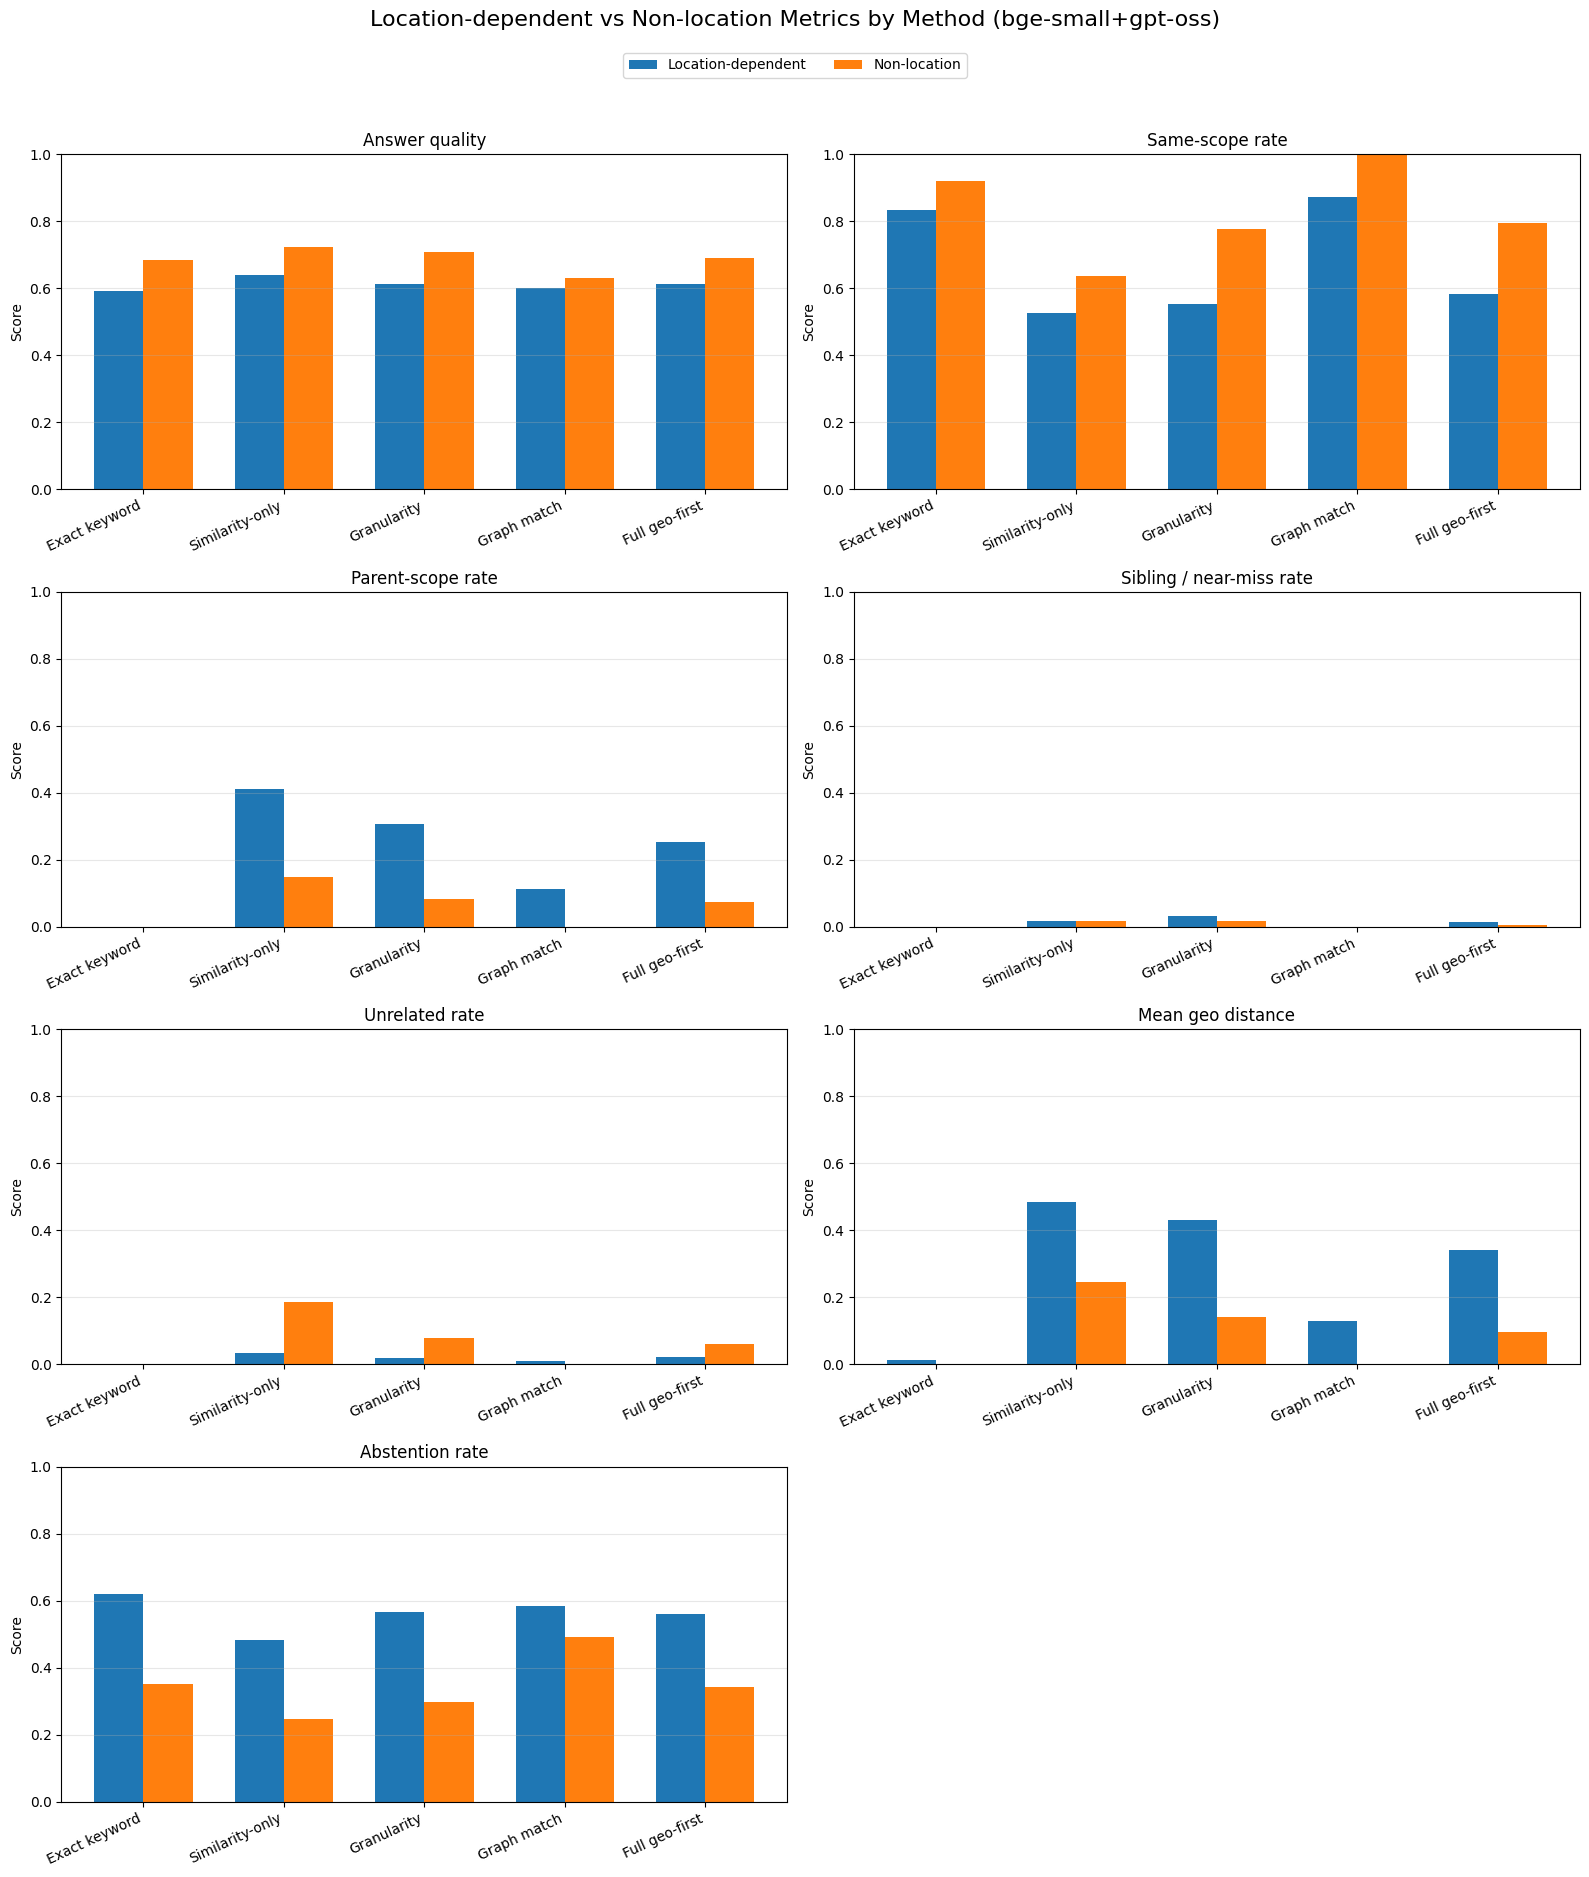

In [34]:
n_metrics = len(plot_metrics)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 18)
)

axes = axes.flatten()

for ax, metric in zip(axes, plot_metrics):

    pivot_df = plot_source.pivot_table(
        index="method",
        columns="location_group",
        values=metric,
        aggfunc="first"
    ).loc[methods_order]

    pivot_df.index = [method_labels[m] for m in pivot_df.index]

    x = np.arange(len(pivot_df.index))
    width = 0.35

    ax.bar(
        x - width / 2,
        pivot_df["Location-dependent"],
        width,
        label="Location-dependent"
    )

    ax.bar(
        x + width / 2,
        pivot_df["Non-location"],
        width,
        label="Non-location"
    )

    ax.set_title(metric_labels[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=25, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)

# remove unused subplot if any
for j in range(len(plot_metrics), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    f"Location-dependent vs Non-location Metrics by Method ({best_model})",
    fontsize=16,
    y=1.04
)

plt.tight_layout()
plt.show()

The full risk-aware method achieves the best overall tradeoff, improving geographic consistency over vanilla retrieval while maintaining strong answer quality without the high abstention of strict filtering methods.

In [ ]:
# | Method              | Geo accuracy | Answer quality | Abstention |
# | ------------------- | ------------ | -------------- | ---------- |
# | Exact keyword match | Very high    | Medium         | Very high  |
# | Similarity-only     | Low          | High           | Medium     |
# | Granularity-only    | Medium       | Medium-high    | High       |
# | Graph match         | Very high    | Low-medium     | Very high  |
# | Full geo-first      | Medium-high  | Medium-high    | High       |


In [25]:
# | Method                | What it shows                                                                                                                                                                                                                                                                 |
# | --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
# | Exact keyword match   | Fails when exact-location documents are missing. High precision, low recall, high abstention.                                                                                                                                                                                 |
# | Similarity-only       | Retrieves semantically relevant passages, but can pull evidence from the wrong jurisdiction. High answer coverage, higher mismatch risk.                                                                                                                                      |
# | Granularity-only      | Helps control jurisdiction level, but does not guarantee the passage is about the correct place.                                                                                                                                                                              |
# | Graph match           | Handles geographic closeness better than keyword exact match, but may still be too restrictive or reduce answer quality.                                                                                                                                                      |
# | Full geo-first method | Uses geographic hierarchy first, then granularity preference, then semantic similarity. It handles mismatch better by answering only when evidence is close enough, warning when evidence is close but imperfect, and abstaining when evidence is geographically unsupported. |


Exact keyword filtering provides high precision when exact local evidence exists, but fails when the corpus lacks documents for the target jurisdiction. Similarity-only retrieval improves coverage, but often retrieves passages from semantically similar yet geographically incorrect jurisdictions. Granularity filtering partially controls the administrative level of retrieved evidence, while graph-based retrieval captures geographic proximity through the jurisdiction hierarchy. The full geo-first method combines these signals by first requiring acceptable graph distance, then preferring matching jurisdiction granularity, and finally ranking candidates by semantic similarity. This allows the system to answer when evidence is geographically compatible, warn when evidence is only partially aligned, and abstain when no suitable geographic evidence is available.

The full method does not simply maximize answer generation; it reduces wrong confident answers by making retrieval geographically accountable.

In [26]:
method_name_map = {
    "exact_match": "Exact keyword match",
    "vanilla": "Similarity-only",
    "granularity": "Granularity-only",
    "graph_match": "Graph match",
    "risk_aware": "Full geo-first"
}

method_order = [
    "exact_match",
    "vanilla",
    "granularity",
    "graph_match",
    "risk_aware"
]

label_map = {
    "exact_match": {
        "Geo accuracy": "Very high",
        "Answer quality": "Medium",
        "Abstention": "Very high"
    },
    "vanilla": {
        "Geo accuracy": "Low",
        "Answer quality": "High",
        "Abstention": "Medium"
    },
    "granularity": {
        "Geo accuracy": "Medium",
        "Answer quality": "Medium-high",
        "Abstention": "High"
    },
    "graph_match": {
        "Geo accuracy": "Very high",
        "Answer quality": "Low-medium",
        "Abstention": "Very high"
    },
    "risk_aware": {
        "Geo accuracy": "Medium-high",
        "Answer quality": "Medium-high",
        "Abstention": "High"
    }
}

def fmt_range(s):
    return f"{s.min():.3f}–{s.max():.3f}"

loc_summary = summary[
    summary["location_group"] == "Location-dependent"
].copy()

rows = []

for method in method_order:
    g = loc_summary[loc_summary["method"] == method]

    rows.append({
        "Method": method_name_map[method],

        "Geo accuracy": label_map[method]["Geo accuracy"],
        "Geo metric same_scope_rate": fmt_range(g["same_scope_rate"]),

        "Answer quality": label_map[method]["Answer quality"],
        "Answer metric mean_answer_similarity": fmt_range(g["mean_answer_similarity"]),

        "Abstention": label_map[method]["Abstention"],
        "Abstention metric": fmt_range(g["abstention_rate"])
    })

final_qual_metric_table = pd.DataFrame(rows)

final_qual_metric_table

,Method,Geo accuracy,Geo metric same_scope_rate,Answer quality,Answer metric mean_answer_similarity,Abstention,Abstention metric
0,Exact keyword match,Very high,0.833–0.837,Medium,0.521–0.593,Very high,0.615–0.747
1,Similarity-only,Low,0.511–0.525,High,0.535–0.641,Medium,0.484–0.729
2,Granularity-only,Medium,0.552–0.566,Medium-high,0.524–0.611,High,0.557–0.765
3,Graph match,Very high,0.873–0.873,Low-medium,0.505–0.600,Very high,0.584–0.783
4,Full geo-first,Medium-high,0.584–0.647,Medium-high,0.515–0.613,High,0.561–0.765


Exact keyword matching and graph matching achieve the strongest geographic alignment but at the cost of high abstention and lower answer quality. Similarity-only retrieval gives the best answer quality but weaker geographic alignment. The full geo-first method improves geographic alignment over similarity-only retrieval while preserving more answer quality than graph-only retrieval, making it the best tradeoff for reducing wrong confident answers.
